# Gibbs Sampler Demo: 21cm Signal and Foreground Separation

A self-contained minimal working example of a joint Gibbs sampler for separating the 21cm HI signal from spectrally-smooth astrophysical foregrounds, with simultaneous inference of the signal power spectrum $P(k)$.

**Data model**: $d = s + f + n$

- $s$ — 21cm signal (Gaussian random field, unknown $P(k)$)
- $f$ — foreground emission (modelled via $n_{\rm fg}$ PCA spectral modes)
- $n \sim \mathcal{N}(0, \sigma^2 I)$ — Gaussian instrumental noise

**Inference** via Gibbs iteration over the joint posterior $p(s, f, S, F \mid d)$:

1. Draw $(s, f) \mid d, S, F$ — solve the preconditioned linear system $Ax = b$
2. Draw $S \mid s$ — per-$k$ inverse-gamma conjugate update
3. Draw $F \mid f$ — inverse-Wishart conjugate update

All data are generated synthetically; no external files are required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, lgmres
from tqdm.notebook import tqdm

from linear_system import Us, Uf, construct_A, construct_b, construct_preconditioner
from gibbs_utils import signal_covariance_sampler as SCS, foreground_covariance_sampler as FCS

## K-space binning helpers

Self-contained functions for the binning of pixels used to form power spectra

In [2]:
def make_kbins(N, nbins):
    """
    Assign each Fourier mode of an N^3 FFT cube to a radial k-bin.

    Returns
    -------
    sig_k : (nbins,) array of bin-centre wavenumbers (units: 1/pixel)
    idxs  : (N^3,) int array — idxs[i] = bin index (1..nbins); 0 reserved for DC.
    """
    freq = np.fft.fftfreq(N)
    KX, KY, KZ = np.meshgrid(freq, freq, freq, indexing='ij')
    Kmag = np.sqrt(KX**2 + KY**2 + KZ**2).flatten()

    k_nz     = Kmag[Kmag > 0]
    k_edges  = np.linspace(k_nz.min(), k_nz.max(), nbins + 1)
    idxs     = np.zeros(N**3, dtype=int)

    for i in range(1, nbins + 1):
        lo, hi = k_edges[i - 1], k_edges[i]
        mask   = (Kmag >= lo) & (Kmag <= hi) if i == nbins else (Kmag >= lo) & (Kmag < hi)
        idxs[mask] = i

    sig_k = 0.5 * (k_edges[:-1] + k_edges[1:])
    return sig_k, idxs


def bin_it(cube, sig_k, idxs):
    """
    Group Fourier modes of a flattened N^3 FFT cube by radial k-bin.

    Returns
    -------
    binned_s : list[array] — one array of mode amplitudes per bin
    k_bins   : list[array] — matching array of k-values (constant within each bin)
    """
    s_flat = cube.flatten()
    binned_s, k_bins = [], []
    for b in np.unique(idxs)[1:]:          # skip bin 0 (DC)
        mask = idxs == b
        binned_s.append(s_flat[mask])
        k_bins.append(np.full(mask.sum(), sig_k[b - 1]))
    return binned_s, k_bins

## Synthetic data generation

In [30]:
rng     = np.random.default_rng(42)
N       = 32          # cube side length  (32^3 voxels — fast enough for a laptop)
n_fg    = 3           # number of foreground PCA modes
sigma_n = 0.2         # noise standard deviation
shape   = (N, N, N)

# ── Signal: Gaussian random field coloured with P(k) ~ k^{-2} ────────────────
kfreq_full = np.fft.fftfreq(N)
kfreq_half = np.fft.rfftfreq(N)
KX, KY, KZ = np.meshgrid(kfreq_full, kfreq_full, kfreq_half, indexing='ij')
Kmag_rfft            = np.sqrt(KX**2 + KY**2 + KZ**2)
Kmag_rfft[0, 0, 0]  = 1.0          # avoid ÷0 at DC; zeroed below

A_sig      = 5e-3
Pk_color   = A_sig * Kmag_rfft**(-2)

wn_k       = np.fft.rfftn(rng.standard_normal(shape), norm='ortho')
signal_k   = wn_k * np.sqrt(Pk_color)
signal_k[0, 0, 0] = 0              # zero DC mode
signal_cube = np.fft.irfftn(signal_k, norm='ortho')

# ── Foregrounds: n_fg power-law spectral templates, orthonormalised via QR ────
freq_axis     = np.linspace(900, 1100, N)       # MHz (3rd cube axis = frequency)
raw_templates = np.stack([(freq_axis / 1000.)**(-2.5 - 0.4*m) for m in range(n_fg)])
evecs, _      = np.linalg.qr(raw_templates.T)  # (N, n_fg) orthonormal columns
evecs         = evecs.T                         # (n_fg, N) — matches Uf convention

fg_amps  = rng.standard_normal((N, N, n_fg)) * 5.0   # sky amplitudes
fg_cube  = fg_amps @ evecs                            # (N, N, N) foreground cube

# ── Noise and data ────────────────────────────────────────────────────────────
noise_cube = rng.normal(0, sigma_n, shape)
data_cube  = signal_cube + fg_cube + noise_cube

print(f"Signal RMS : {signal_cube.std():.4f}")
print(f"Foreground RMS: {fg_cube.std():.4f}")
print(f"Noise RMS  : {noise_cube.std():.4f}  (sigma_n = {sigma_n})")

Signal RMS : 0.1999
Foreground RMS: 1.5190
Noise RMS  : 0.2005  (sigma_n = 0.2)


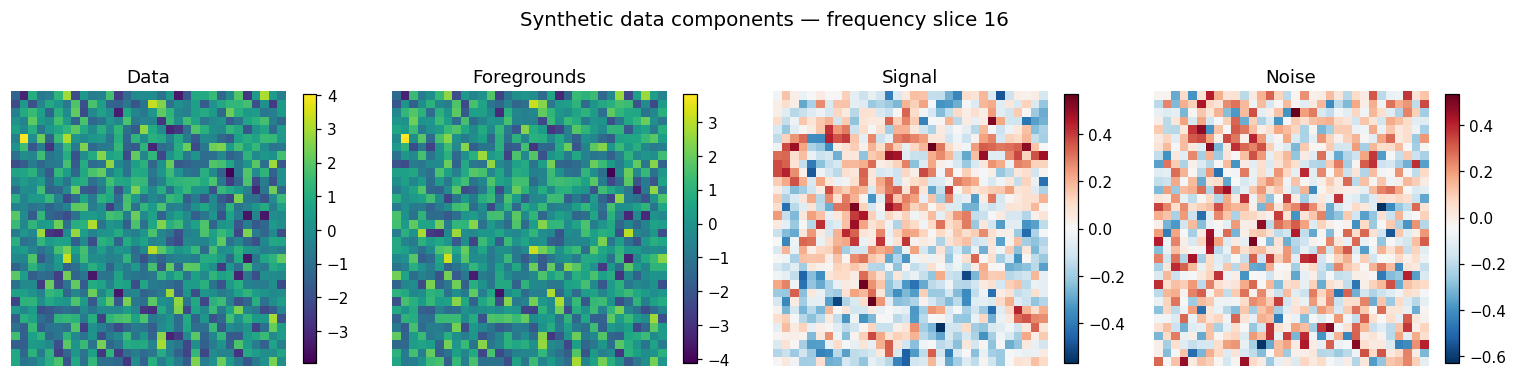

In [31]:
freq_idx = N // 2
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=110)
for ax, (cube, title, cmap) in zip(axes, [
        (data_cube,   'Data',        'viridis'),
        (fg_cube,     'Foregrounds', 'viridis'),
        (signal_cube, 'Signal',      'RdBu_r'),
        (noise_cube,  'Noise',       'RdBu_r')]):
    im = ax.imshow(cube[:, :, freq_idx], cmap=cmap, origin='lower')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.suptitle(f'Synthetic data components — frequency slice {freq_idx}', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Model setup and initialisation

In [32]:
# ── True modes (used to initialise, and to compare against later) ─────────────
s_true = Us(signal_cube, True)     # rfftn  → (N, N, N//2+1)
f_true = Uf(evecs, fg_cube, True)  # U_f^T  → (N, N, n_fg)

rfft_shape = s_true.shape          # (N, N, N//2+1)
rfft_len   = s_true.size           # N * N * (N//2+1)
f_shape    = f_true.shape          # (N, N, n_fg)
f_len      = f_true.size           # N * N * n_fg
total_len  = 2 * rfft_len + f_len  # length of joint solution vector x

# ── Noise covariance (diagonal, uniform noise — no flagging) ──────────────────
N_inv  = np.ones(N**3) / sigma_n**2
w      = np.ones(N**3)
Nw_inv = N_inv

# ── k-bin setup ───────────────────────────────────────────────────────────────
n_k_bins    = 8
sig_k, idxs = make_kbins(N, n_k_bins)
unique_bins  = np.unique(idxs)[1:]   # bins 1..n_k_bins  (skip DC = 0)

# ── Initialise S: sample from a noisy perturbation of the true signal ─────────
s_offset = signal_cube * rng.normal(1.0, 2.0, shape)     # ~200 % scatter
binned_s0, k_bins0 = bin_it(
    np.fft.fftn(s_offset - s_offset.mean(), norm='ortho'), sig_k, idxs)
_, PkSample0 = SCS(np.concatenate(binned_s0), np.concatenate(k_bins0))

S = np.zeros(N**3)
for gg, b in enumerate(unique_bins):
    S[idxs == b] = PkSample0[gg]
S[idxs == 0] = 1e30                    # DC mode — uninformative prior
Pk_init = np.array(PkSample0)

# ── Initialise F: from perturbed true foreground amplitudes ───────────────────
f_init = f_true * rng.normal(1.0, 0.05, f_shape)   # 5 % perturbation
f_mean = f_init
F_mat  = FCS(f_init.reshape(N**2, n_fg))
F      = np.diag(F_mat)    # keep diagonal elements only (mode-mode covariances)

# ── Starting solution vector  x = [ Re(s), Im(s), f ] ─────────────────────────
s_mean = np.zeros(rfft_shape)
x      = np.concatenate([s_mean.real.flatten(), s_mean.imag.flatten(),
                          f_mean.flatten()])

print(f"total_len = {total_len}  ({2*rfft_len} signal + {f_len} foreground)")

total_len = 37888  (34816 signal + 3072 foreground)


## Gibbs sampler

Each iteration:
1. **Draw $(s, f) \mid d, S, F$** — solve the block-preconditioned linear system $Ax = b$ with LGMRES
2. **Draw $S \mid s$** — per-$k$ inverse-gamma conjugate update
3. **Draw $F \mid f$** — inverse-Wishart conjugate update

The solution vector is $x = [\text{Re}(\hat{s}),\, \text{Im}(\hat{s}),\, f]$ where $\hat{s}$ are the real-FFT Fourier modes of the signal.

In [34]:
N_samples = 300
burn_in   = 100

Pk_trace = []                   # per-bin P(k) sample at every iteration
s_sum    = np.zeros(shape)      # accumulate for posterior mean field
n_post   = 0

# LinearOperator wrapping A  (S, F, evecs captured by closure; updated each iteration)
def A_flat(x_in):
    return construct_A(x_in, S, Nw_inv, F, w, evecs,
                       rfft_len, rfft_shape, f_len, f_shape).flatten()

L     = LinearOperator(matvec=A_flat, rmatvec=A_flat, shape=(total_len, total_len))
N_inv_scalar = 1.0 / sigma_n**2

precond_apply = construct_preconditioner(
    S, N_inv_scalar, F, evecs, rfft_len, rfft_shape, f_len, f_shape)
M_inv = LinearOperator((total_len, total_len), matvec=precond_apply)

for rr in tqdm(range(N_samples)):
    x0 = x   # warm start from previous sample

    # ── 1. Draw (s, f) via preconditioned LGMRES ─────────────────────────────
    ws  = np.fft.rfftn(rng.standard_normal(shape), norm='ortho').flatten()
    wf  = rng.standard_normal(f_shape)
    wd  = rng.standard_normal(N**3)

    rhs = construct_b(S, N_inv, F, w, s_mean, f_mean, evecs, data_cube, ws, wf, wd)
    x, _ = lgmres(L, rhs.flatten(), x0=x0, rtol=1e-6, atol=0, M=M_inv)

    # ── 2. Draw S (power spectrum) ────────────────────────────────────────────
    s_k    = (x[:rfft_len].reshape(rfft_shape)
              + x[rfft_len:2*rfft_len].reshape(rfft_shape) * 1j)
    s_real = Us(s_k, False)
    s_fft  = np.fft.fftn(s_real - s_real.mean(), norm='ortho')

    binned_s, k_bins_s = bin_it(s_fft, sig_k, idxs)
    _, PkSample = SCS(np.concatenate(binned_s), np.concatenate(k_bins_s))

    S = np.zeros(N**3)
    for gg, b in enumerate(unique_bins):
        S[idxs == b] = PkSample[gg]
    S[idxs == 0] = 1e30
    Pk_trace.append(np.array(PkSample))

    # ── 3. Draw F (foreground covariance) ────────────────────────────────────
    f_ms       = x[2*rfft_len:2*rfft_len + f_len].reshape(f_shape).real
    f_centered = (f_ms - f_mean).reshape(N**2, n_fg)
    # Small jitter prevents a singular scatter matrix at early iterations
    f_centered += rng.normal(0, 1e-8, f_centered.shape)
    F = np.diag(FCS(f_centered))

    # ── Rebuild preconditioner with updated S and F ───────────────────────────
    precond_apply = construct_preconditioner(
        S, N_inv_scalar, F, evecs, rfft_len, rfft_shape, f_len, f_shape)
    M_inv = LinearOperator((total_len, total_len), matvec=precond_apply)

    # ── Accumulate signal field (post-burn-in) ────────────────────────────────
    if rr >= burn_in:
        s_sum  += s_real
        n_post += 1

Pk_trace         = np.array(Pk_trace)           # (N_samples, n_k_bins)
s_posterior_mean = s_sum / n_post
print(f"Done — {n_post} post-burn-in samples.")

Done — 200 post-burn-in samples.


## Results

### Power spectrum recovery

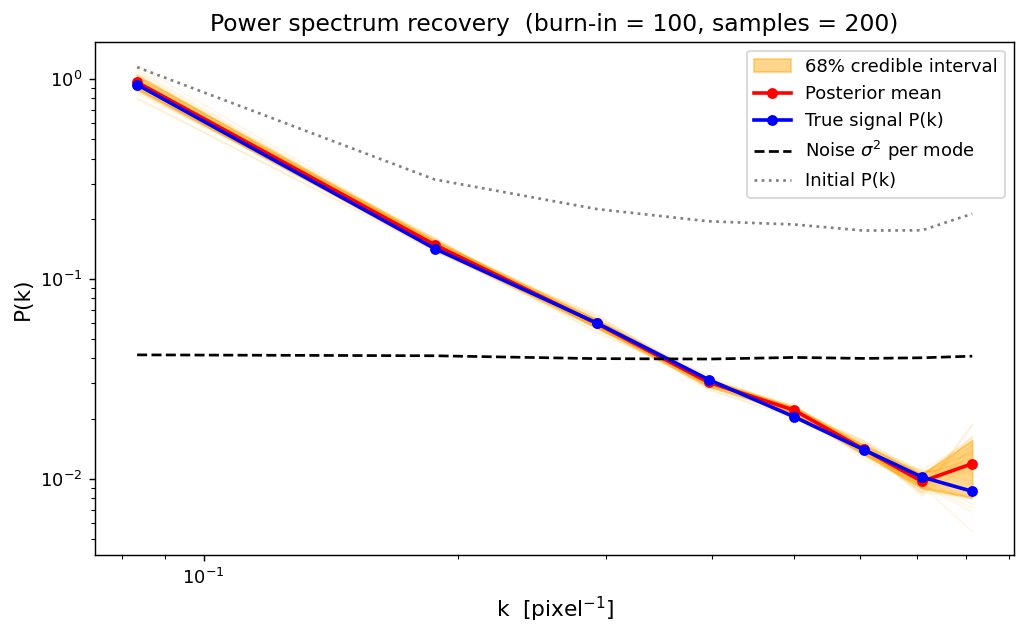

In [35]:
# True P(k) from the generated signal cube
binned_s_true, _ = bin_it(
    np.fft.fftn(signal_cube - signal_cube.mean(), norm='ortho'), sig_k, idxs)
Pk_true  = np.array([np.mean(np.abs(b)**2) for b in binned_s_true])

# Noise P(k)
binned_n, _ = bin_it(
    np.fft.fftn(noise_cube - noise_cube.mean(), norm='ortho'), sig_k, idxs)
Pk_noise = np.array([np.mean(np.abs(b)**2) for b in binned_n])

# Posterior statistics (post-burn-in samples)
Pk_post = Pk_trace[burn_in:]
Pk_mean = Pk_post.mean(axis=0)
Pk_lo   = np.percentile(Pk_post, 16, axis=0)
Pk_hi   = np.percentile(Pk_post, 84, axis=0)

fig, ax = plt.subplots(figsize=(8, 5), dpi=130)

# Individual samples (thinned for clarity)
for pk in Pk_post[::5]:
    ax.plot(sig_k, pk, color='orange', alpha=0.12, lw=0.8)

ax.fill_between(sig_k, Pk_lo, Pk_hi, color='orange', alpha=0.45,
                label='68% credible interval')
ax.plot(sig_k, Pk_mean,  'r-o',  lw=2,   ms=5, label='Posterior mean')
ax.plot(sig_k, Pk_true,  'b-o',  lw=2,   ms=5, label='True signal P(k)')
ax.plot(sig_k, Pk_noise, 'k--',  lw=1.5,       label=r'Noise $\sigma^2$ per mode')
ax.plot(sig_k, Pk_init,  color='grey', ls=':', lw=1.5, label='Initial P(k)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k  [pixel$^{-1}$]', fontsize=12)
ax.set_ylabel('P(k)', fontsize=12)
ax.set_title(f'Power spectrum recovery  (burn-in = {burn_in}, samples = {len(Pk_post)})',
             fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Signal field recovery

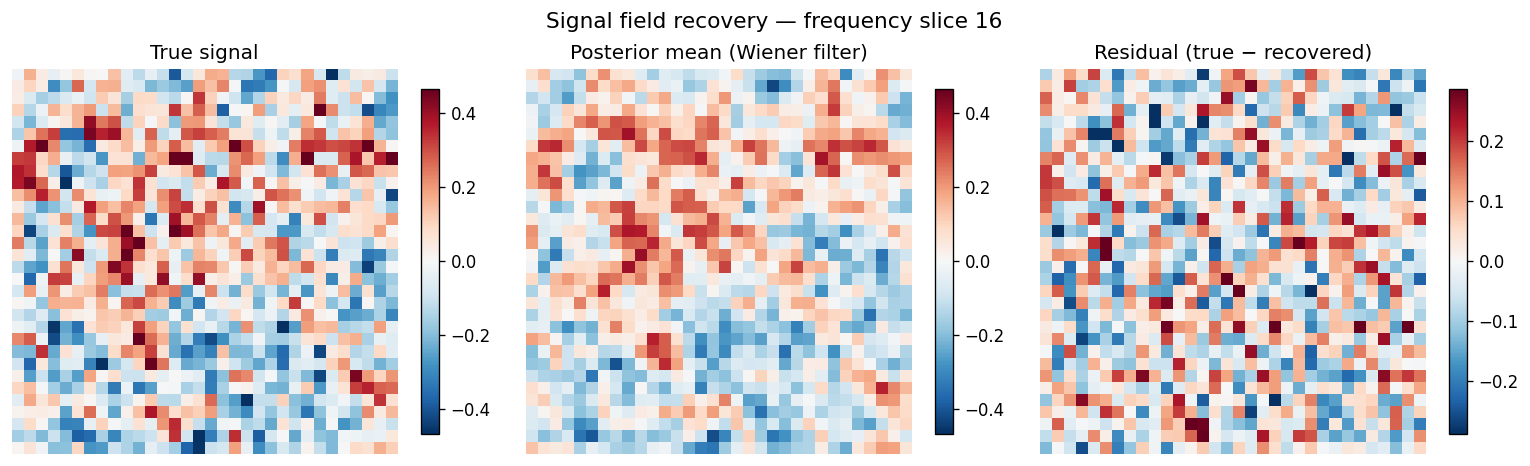

In [36]:
freq_idx = N // 2
vmax = np.percentile(np.abs(signal_cube), 98)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=120)

im0 = axes[0].imshow(signal_cube[:, :, freq_idx],     cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax, origin='lower')
axes[0].set_title('True signal', fontsize=12)
plt.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(s_posterior_mean[:, :, freq_idx], cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax, origin='lower')
axes[1].set_title('Posterior mean (Wiener filter)', fontsize=12)
plt.colorbar(im1, ax=axes[1], shrink=0.85)

residual = signal_cube[:, :, freq_idx] - s_posterior_mean[:, :, freq_idx]
vmax_r   = np.percentile(np.abs(residual), 98)
im2 = axes[2].imshow(residual,                         cmap='RdBu_r',
                     vmin=-vmax_r, vmax=vmax_r, origin='lower')
axes[2].set_title('Residual (true − recovered)', fontsize=12)
plt.colorbar(im2, ax=axes[2], shrink=0.85)

for ax in axes:
    ax.axis('off')
plt.suptitle(f'Signal field recovery — frequency slice {freq_idx}', fontsize=13)
plt.tight_layout()
plt.show()